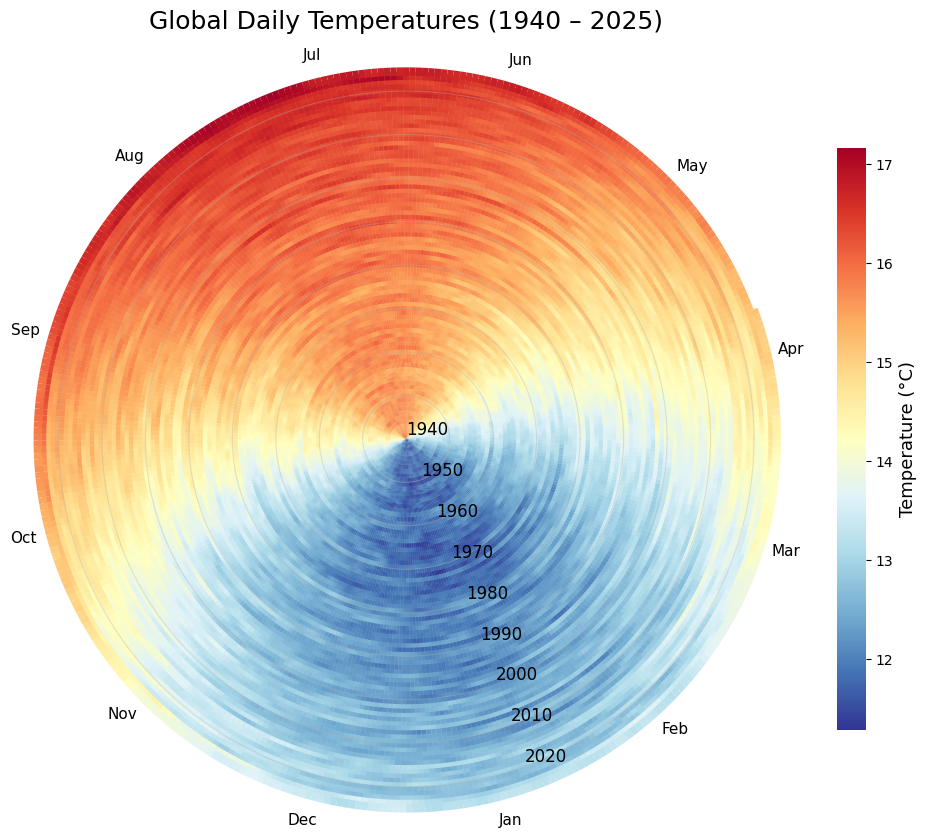

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


def spiral_temperature_plot(
    csv_path: str,
    *,
    cmap: str = "RdYlBu_r",
    linewidth: float = 6,
    figsize: tuple[int, int] = (10, 10),
    outfile: str | None = "temp_spiral_ribbon.png",
):
    """
    Draw a polar-spiral ribbon of daily global temperatures.

    Parameters
    ----------
    csv_path : str   – CSV with columns: year, day_of_year (1-366), temperature.
    cmap     : str   – Matplotlib colormap name.
    linewidth: float – Width of the ribbon.
    figsize  : tuple – Figure size in inches.
    outfile  : str|None – Path to save the figure (PNG, SVG …).  None ⇒ don’t save.
    """
    # --------------------------------------------------
    # 1. Load and prepare data
    # --------------------------------------------------
    df = (
        pd.read_csv(csv_path)
        .query("day_of_year <= 365")                               # drop leap day
        .assign(n_day=lambda d: (d.year - d.year.min()) * 365      # running day index
                          + d.day_of_year - 1)
    )

    year_span = df.year.nunique()          # number of concentric “turns”
    outer_radius = year_span

    # --------------------------------------------------
    # 2. Geometry
    # --------------------------------------------------
    theta = 2 * np.pi * (df.n_day % 365) / 365 - np.pi / 2
    r = df.n_day / 365
    xy = np.column_stack([theta, r])

    segments = np.stack([xy[:-1], xy[1:]], axis=1)
    norm = plt.Normalize(df.temperature.min(), df.temperature.max())

    # --------------------------------------------------
    # 3. Plot
    # --------------------------------------------------
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=figsize)

    lc = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        linewidth=linewidth,
        capstyle="butt",
        zorder=1,         
    )
    lc.set_array(df.temperature.iloc[:-1].values)
    ax.add_collection(lc)

    # --------------------------------------------------
    # 4. Axis styling
    # --------------------------------------------------
    decade_ticks = np.arange(0, year_span + 1, 10)
    ax.set_rticks(decade_ticks)
    ax.set_yticklabels(df.year.min() + decade_ticks, fontsize=12)
    ax.set_rlabel_position(290)
    ax.yaxis.grid(True, lw=0.8, alpha=0.35)
    ax.xaxis.grid(False)
    ax.set_rlim(0, outer_radius + 2)           # breathing room
    ax.set_xticks([])
    ax.spines["polar"].set_visible(False)

    # month labels
    month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                   "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    mid_days = np.cumsum([31, 28, 31, 30, 31, 30,
                          31, 31, 30, 31, 30, 31]) - 15.5
    for name, mid in zip(month_names, mid_days):
        ax.text(
            2 * np.pi * mid / 365 - np.pi / 2,
            outer_radius + 5,
            name,
            ha="center",
            va="center",
            fontsize=11,
        )

    # --------------------------------------------------
    # 5. Colorbar & title
    # --------------------------------------------------
    cbar = fig.colorbar(lc, ax=ax, shrink=0.6, pad=0.05)
    cbar.outline.set_visible(False)
    cbar.set_label("Temperature (°C)", fontsize=13)

    year_min, year_max = df.year.min(), df.year.max()
    ax.set_title(f"Global Daily Temperatures ({year_min} – {year_max})",
                 pad=20, fontsize=18)

    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=500, bbox_inches="tight")
    plt.show()
    return fig, ax


# ------------------------------------------------------------------
# Example usage
# ------------------------------------------------------------------
if __name__ == "__main__":
    spiral_temperature_plot("era5_daily_preindustrial.csv")
